## Assignment No.16

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("anime.csv")
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nSummary Statistics:\n", df.describe())
print("\nUnique Anime Types:\n", df['type'].value_counts())

Shape: (12294, 7)

Column Names: ['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

Data Types:
 anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

First 5 Rows:
    anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy

In [2]:
print("Missing values before cleaning:\n", df.isnull().sum())

# Drop rows where genre or name is missing (core features for recommendation)
df = df.dropna(subset=['genre', 'name'])

# Fill missing rating with median rating
df['rating'] = df['rating'].fillna(df['rating'].median())

# Fill missing episodes with median episodes
df['episodes'] = df['episodes'].replace('Unknown', np.nan)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

# Fill missing type with mode
df['type'] = df['type'].fillna(df['type'].mode()[0])

# Fill missing members with median
df['members'] = df['members'].fillna(df['members'].median())

df = df.drop_duplicates(subset=['name'])
df = df.reset_index(drop=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Missing values before cleaning:
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values after cleaning:
 anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

Shape after cleaning: (12230, 7)


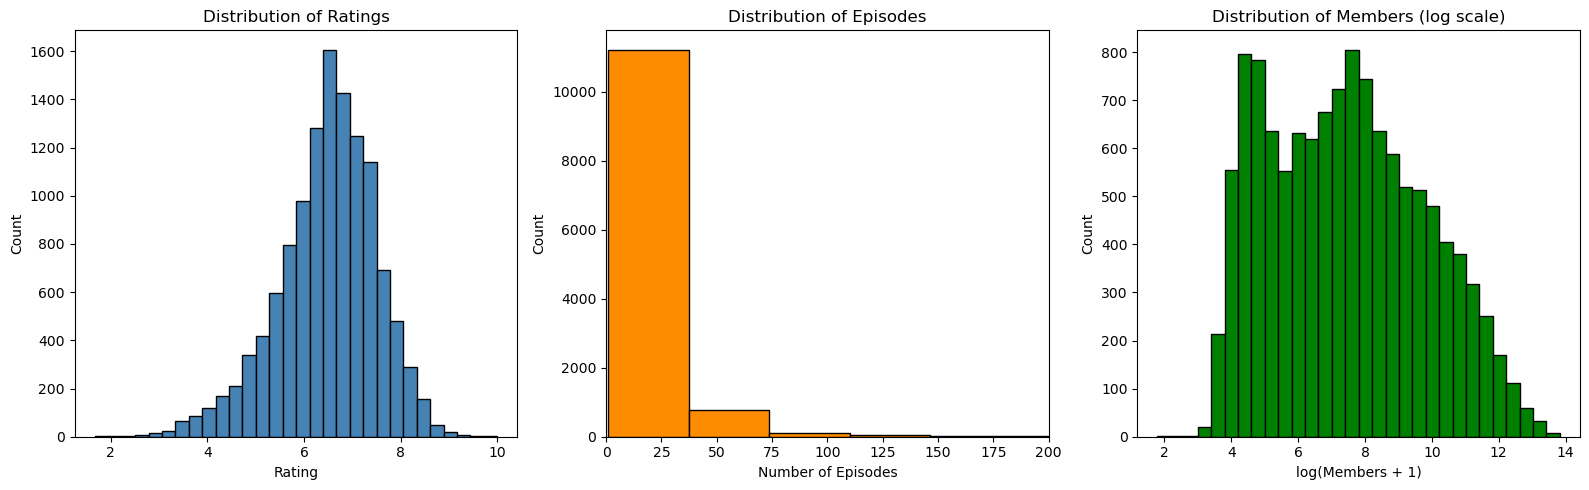

In [3]:
#Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['rating'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

axes[1].hist(df['episodes'].dropna(), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Episodes')
axes[1].set_xlabel('Number of Episodes')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 200)

axes[2].hist(np.log1p(df['members']), bins=30, color='green', edgecolor='black')
axes[2].set_title('Distribution of Members (log scale)')
axes[2].set_xlabel('log(Members + 1)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

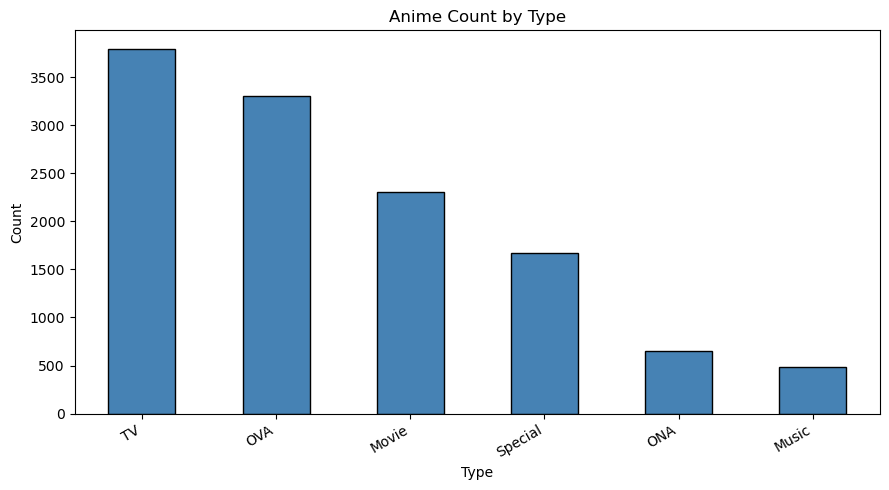

In [4]:
#Anime Type Distribution
type_counts = df['type'].value_counts()

plt.figure(figsize=(9, 5))
type_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Anime Count by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('type_distribution.png')
plt.show()

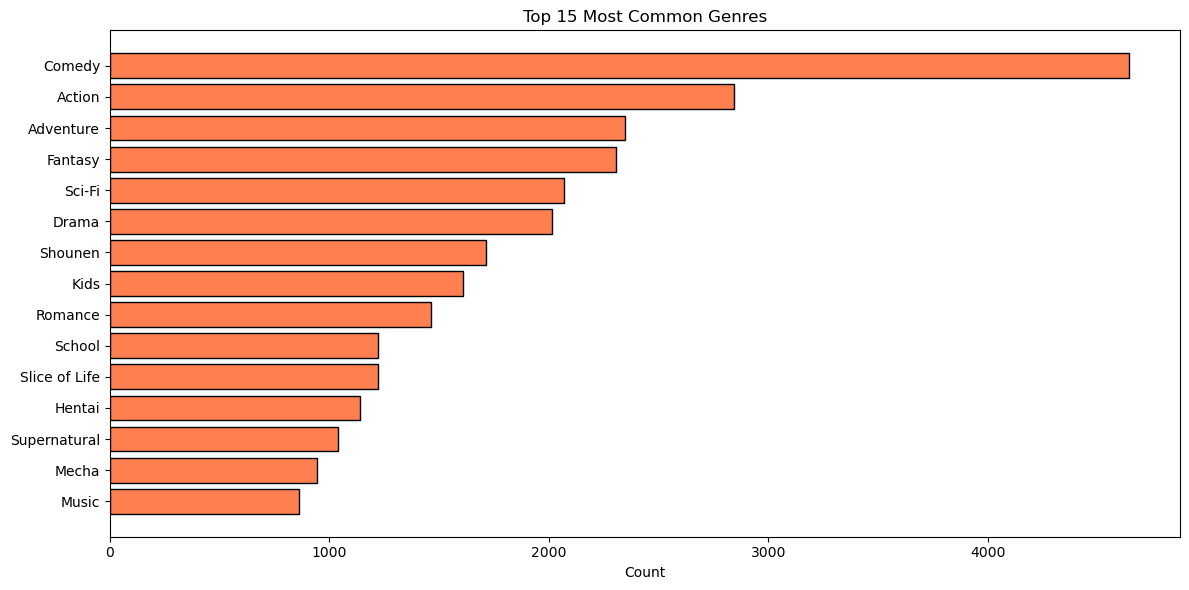

In [5]:
#Top 15 Genres
from collections import Counter

all_genres = df['genre'].dropna().str.split(', ')
genre_flat = [g.strip() for sublist in all_genres for g in sublist]
genre_counts = Counter(genre_flat)
genre_df = pd.DataFrame(genre_counts.most_common(15), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
plt.barh(genre_df['Genre'][::-1], genre_df['Count'][::-1], color='coral', edgecolor='black')
plt.title('Top 15 Most Common Genres')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('top_genres.png')
plt.show()

Top 10 Rated Anime:
                                    name  rating  type  members
Taka no Tsume 8: Yoshida-kun no X-Files   10.00 Movie       13
            Spoon-hime no Swing Kitchen    9.60    TV       47
                       Mogura no Motoro    9.50 Movie       62
                         Kimi no Na wa.    9.37 Movie   200630
                           Kahei no Umi    9.33 Movie       44
       Fullmetal Alchemist: Brotherhood    9.26    TV   793665
                               Gintama°    9.25    TV   114262
        Yakusoku: Africa Mizu to Midori    9.25   OVA       53
                            Steins;Gate    9.17    TV   673572
                          Gintama&#039;    9.16    TV   151266


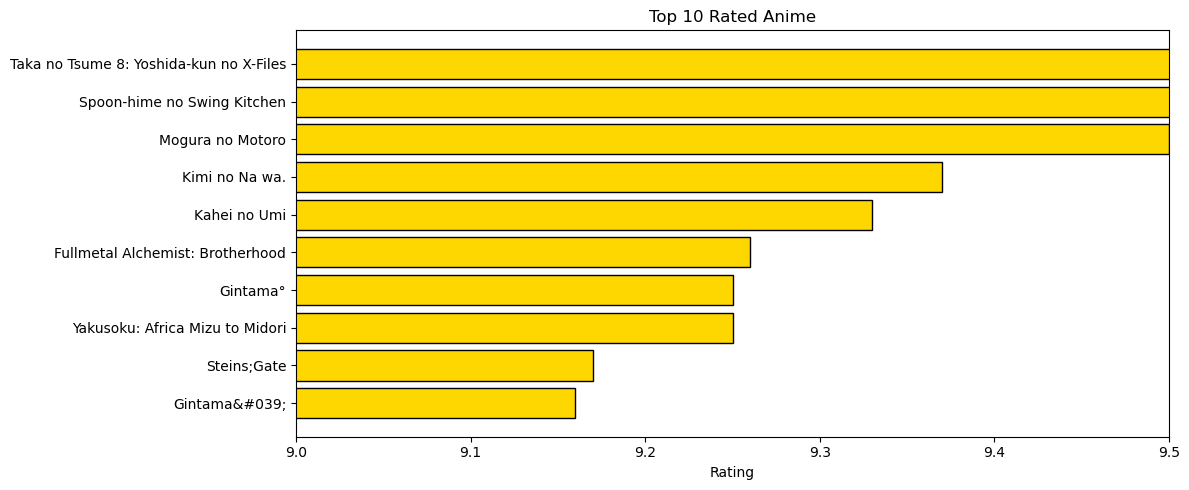

In [6]:
# Top Rated Anime
top_rated = df.nlargest(10, 'rating')[['name', 'rating', 'type', 'members']]
print("Top 10 Rated Anime:\n", top_rated.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.barh(top_rated['name'][::-1], top_rated['rating'][::-1], color='gold', edgecolor='black')
plt.title('Top 10 Rated Anime')
plt.xlabel('Rating')
plt.xlim(9.0, 9.5)
plt.tight_layout()
plt.savefig('top_rated.png')
plt.show()

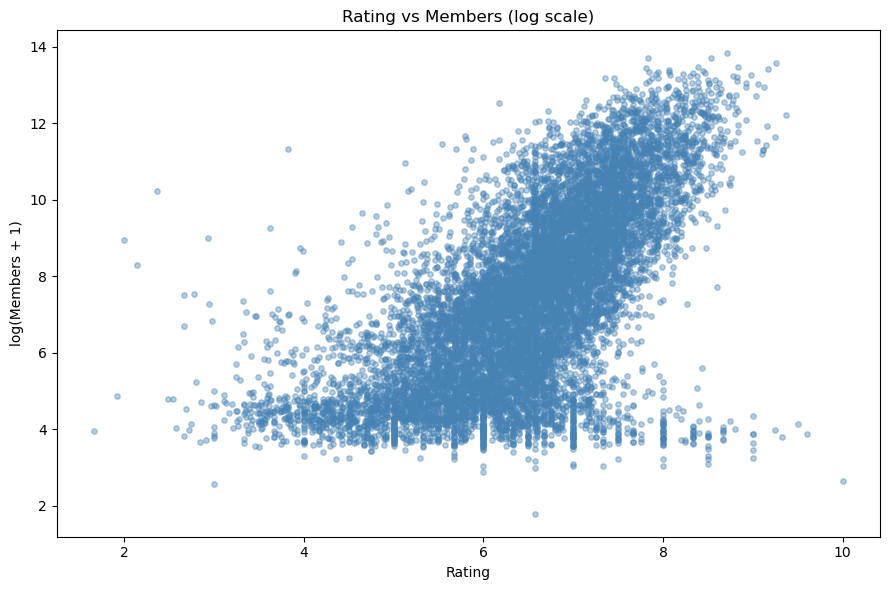

In [7]:
#Rating vs Members Scatter
plt.figure(figsize=(9, 6))
plt.scatter(df['rating'], np.log1p(df['members']), alpha=0.4, color='steelblue', s=15)
plt.title('Rating vs Members (log scale)')
plt.xlabel('Rating')
plt.ylabel('log(Members + 1)')
plt.tight_layout()
plt.savefig('rating_vs_members.png')
plt.show()

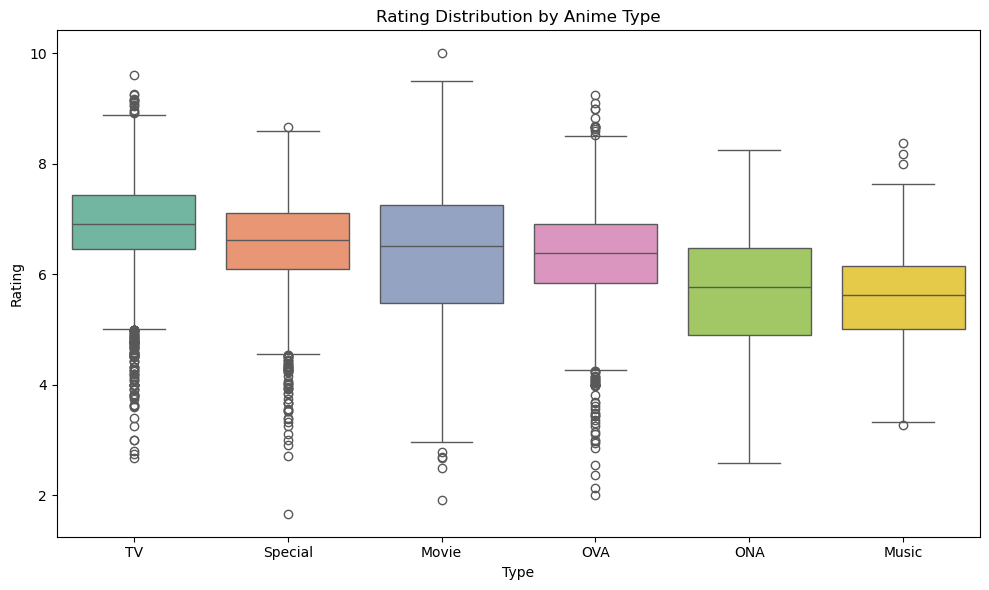

In [8]:
#Boxplot - Rating by Type
plt.figure(figsize=(10, 6))
order = df.groupby('type')['rating'].median().sort_values(ascending=False).index
sns.boxplot(x='type', y='rating', data=df, order=order, palette='Set2')
plt.title('Rating Distribution by Anime Type')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('rating_by_type.png')
plt.show()

In [9]:
#Feature Extraction: TF-IDF on Genre + Type
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

# Combine genre and type into a content string for TF-IDF
df['content'] = df['genre'].fillna('') + ' ' + df['type'].fillna('')

tfidf = TfidfVectorizer(stop_words='english', token_pattern=r"(?u)\b\w[\w-]*\b")
tfidf_matrix = tfidf.fit_transform(df['content'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Sample Feature Names:", tfidf.get_feature_names_out()[:20])

TF-IDF Matrix Shape: (12230, 50)
Sample Feature Names: ['action' 'adventure' 'ai' 'arts' 'cars' 'comedy' 'dementia' 'demons'
 'drama' 'ecchi' 'fantasy' 'game' 'harem' 'hentai' 'historical' 'horror'
 'josei' 'kids' 'life' 'magic']


In [10]:
#Feature Extraction: Normalize Numerical Features & Build Final Feature Matrix
from scipy.sparse import hstack, csr_matrix

scaler = MinMaxScaler()

# Normalize rating, members, episodes
num_features = df[['rating', 'members', 'episodes']].fillna(0)
num_scaled = scaler.fit_transform(num_features)
num_sparse = csr_matrix(num_scaled)

# Encode type as dummy variables
type_dummies = pd.get_dummies(df['type'], prefix='type')
type_sparse = csr_matrix(type_dummies.values)

# Combine TF-IDF + numerical + type features
feature_matrix = hstack([tfidf_matrix, num_sparse, type_sparse])
print("Combined Feature Matrix Shape:", feature_matrix.shape)

Combined Feature Matrix Shape: (12230, 59)


In [2]:
#Recommendation Function: Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(anime_name, top_n=10, threshold=0.0):
    """
    Recommends similar anime based on cosine similarity.

    Parameters:
    -----------
    anime_name : str  - Title of the target anime
    top_n      : int  - Number of recommendations to return
    threshold  : float - Minimum similarity score (0.0 to 1.0)

    Returns:
    --------
    DataFrame with recommended anime and their similarity scores
    """
    # Check if anime exists
    matches = df[df['name'].str.lower() == anime_name.lower()]
    if matches.empty:
        # Try partial match
        matches = df[df['name'].str.lower().str.contains(anime_name.lower(), na=False)]
        if matches.empty:
            print(f"Anime '{anime_name}' not found in dataset.")
            return None

    idx = matches.index[0]
    print(f"Found: {df.loc[idx, 'name']} | Genre: {df.loc[idx, 'genre']} | Rating: {df.loc[idx, 'rating']}")

    # Compute cosine similarity for this anime against all others
    anime_vector = feature_matrix[idx]
    sim_scores = cosine_similarity(anime_vector, feature_matrix).flatten()

    # Create similarity dataframe
    sim_df = pd.DataFrame({
        'index': range(len(sim_scores)),
        'similarity': sim_scores
    })

    # Remove the target anime itself, apply threshold, sort
    sim_df = sim_df[sim_df['index'] != idx]
    sim_df = sim_df[sim_df['similarity'] >= threshold]
    sim_df = sim_df.sort_values('similarity', ascending=False).head(top_n)

    # Map back to anime info
    results = df.loc[sim_df['index'], ['name', 'genre', 'type', 'rating', 'members']].copy()
    results['similarity_score'] = sim_df['similarity'].values

    return results.reset_index(drop=True)

In [12]:
#Test the Recommendation Function
# Test 1: Action anime
print("=" * 60)
print("RECOMMENDATIONS FOR: Death Note")
print("=" * 60)
rec1 = get_recommendations("Death Note", top_n=10)
print(rec1[['name', 'genre', 'rating', 'similarity_score']].to_string(index=False))

RECOMMENDATIONS FOR: Death Note
Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
                         name                                                           genre  rating  similarity_score
             Mirai Nikki (TV) Action, Mystery, Psychological, Shounen, Supernatural, Thriller    8.07          0.933211
              Mousou Dairinin   Drama, Mystery, Police, Psychological, Supernatural, Thriller    7.74          0.884093
    Higurashi no Naku Koro ni          Horror, Mystery, Psychological, Supernatural, Thriller    8.17          0.883803
Higurashi no Naku Koro ni Kai                  Mystery, Psychological, Supernatural, Thriller    8.41          0.878800
                      Another                 Horror, Mystery, School, Supernatural, Thriller    7.88          0.859606
                      Monster Drama, Horror, Mystery, Police, Psychological, Seinen, Thriller    8.72          0.858701
            Zankyou no Terror  

In [13]:
# Test 2: Romance anime
print("\n" + "=" * 60)
print("RECOMMENDATIONS FOR: Kimi no Na wa.")
print("=" * 60)
rec2 = get_recommendations("Kimi no Na wa.", top_n=10)
print(rec2[['name', 'genre', 'rating', 'similarity_score']].to_string(index=False))


RECOMMENDATIONS FOR: Kimi no Na wa.
Found: Kimi no Na wa. | Genre: Drama, Romance, School, Supernatural | Rating: 9.37
                                                 name                                        genre  rating  similarity_score
                Aura: Maryuuin Kouga Saigo no Tatakai Comedy, Drama, Romance, School, Supernatural    7.67          0.974786
                                             Harmonie                  Drama, School, Supernatural    7.52          0.948011
                        Kokoro ga Sakebitagatterunda.                       Drama, Romance, School    8.32          0.945761
                                            Air Movie                 Drama, Romance, Supernatural    7.39          0.942475
                                        Clannad Movie              Drama, Fantasy, Romance, School    7.35          0.911579
Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou Iinkai               Comedy, Drama, Romance, School    6.57          0.908505
     

In [14]:
# Test 3: Adventure/Shounen anime
print("\n" + "=" * 60)
print("RECOMMENDATIONS FOR: Fullmetal Alchemist: Brotherhood")
print("=" * 60)
rec3 = get_recommendations("Fullmetal Alchemist: Brotherhood", top_n=10)
print(rec3[['name', 'genre', 'rating', 'similarity_score']].to_string(index=False))


RECOMMENDATIONS FOR: Fullmetal Alchemist: Brotherhood
Found: Fullmetal Alchemist: Brotherhood | Genre: Action, Adventure, Drama, Fantasy, Magic, Military, Shounen | Rating: 9.26
                                                 name                                                               genre  rating  similarity_score
                                  Fullmetal Alchemist Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen    8.33          0.987072
                                           Fairy Tail                  Action, Adventure, Comedy, Fantasy, Magic, Shounen    8.22          0.920811
                         Magi: The Labyrinth of Magic                          Action, Adventure, Fantasy, Magic, Shounen    8.24          0.902951
                           Magi: The Kingdom of Magic                          Action, Adventure, Fantasy, Magic, Shounen    8.50          0.892232
                                    Fairy Tail (2014)                  Action, Ad

Effect of Threshold on Recommendations for 'Death Note':

Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
Threshold 0.0 → 20 recommendations
Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
Threshold 0.2 → 20 recommendations
Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
Threshold 0.4 → 20 recommendations
Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
Threshold 0.6 → 20 recommendations
Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71
Threshold 0.8 → 17 recommendations


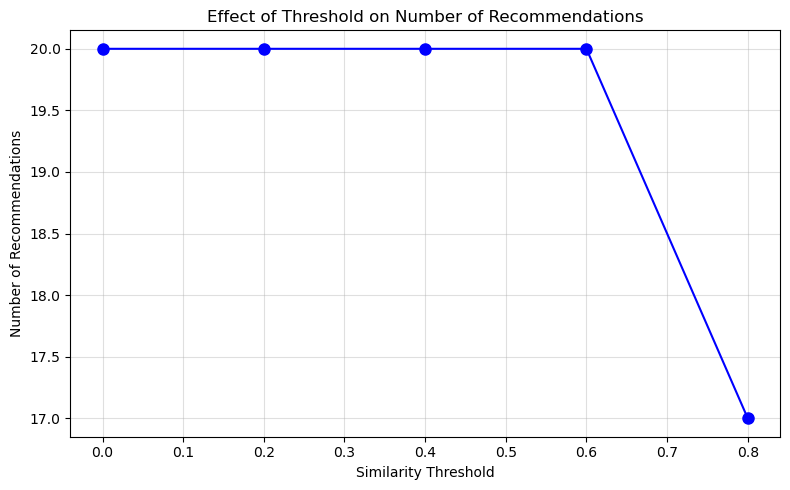

In [15]:
#Threshold Experiment
thresholds = [0.0, 0.2, 0.4, 0.6, 0.8]
anime_test = "Death Note"
print(f"Effect of Threshold on Recommendations for '{anime_test}':\n")

results_count = []
for t in thresholds:
    rec = get_recommendations(anime_test, top_n=20, threshold=t)
    count = len(rec) if rec is not None else 0
    results_count.append(count)
    print(f"Threshold {t:.1f} → {count} recommendations")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, results_count, 'bo-', markersize=8)
plt.title('Effect of Threshold on Number of Recommendations')
plt.xlabel('Similarity Threshold')
plt.ylabel('Number of Recommendations')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('threshold_experiment.png')
plt.show()

Found: Death Note | Genre: Mystery, Police, Psychological, Supernatural, Thriller | Rating: 8.71


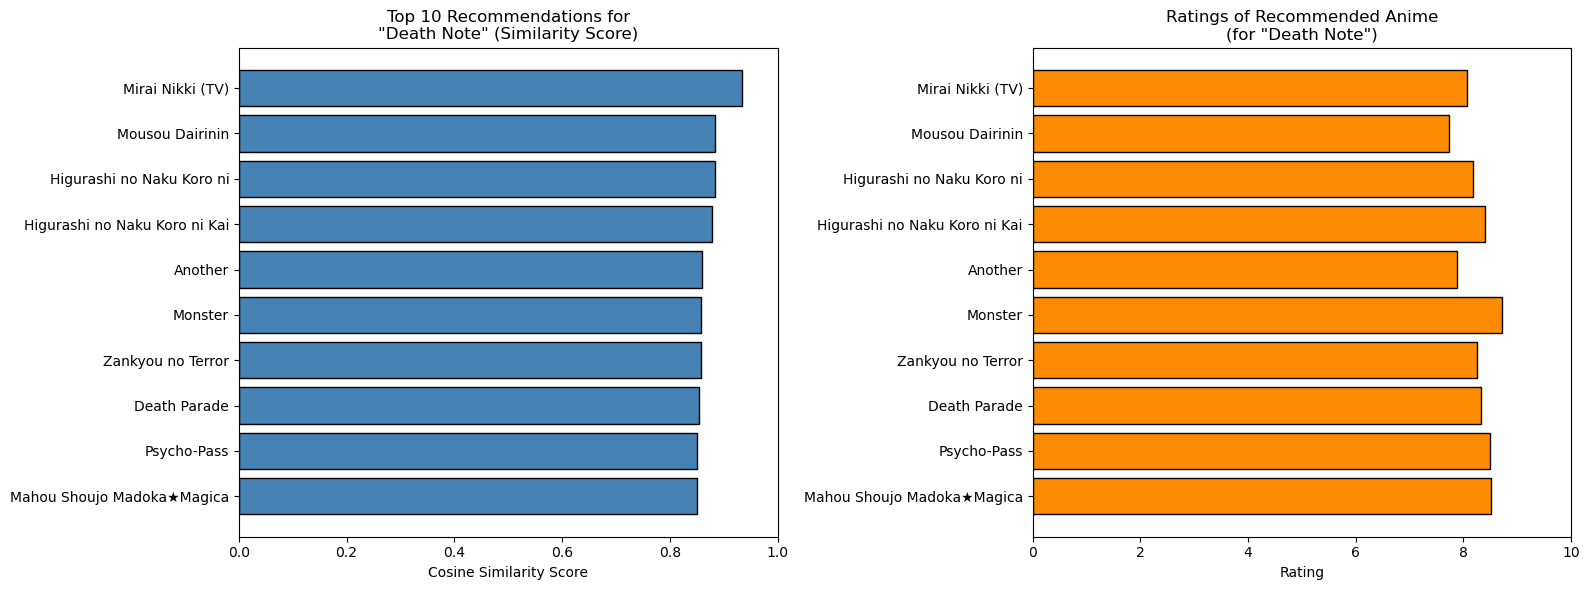

Found: Kimi no Na wa. | Genre: Drama, Romance, School, Supernatural | Rating: 9.37


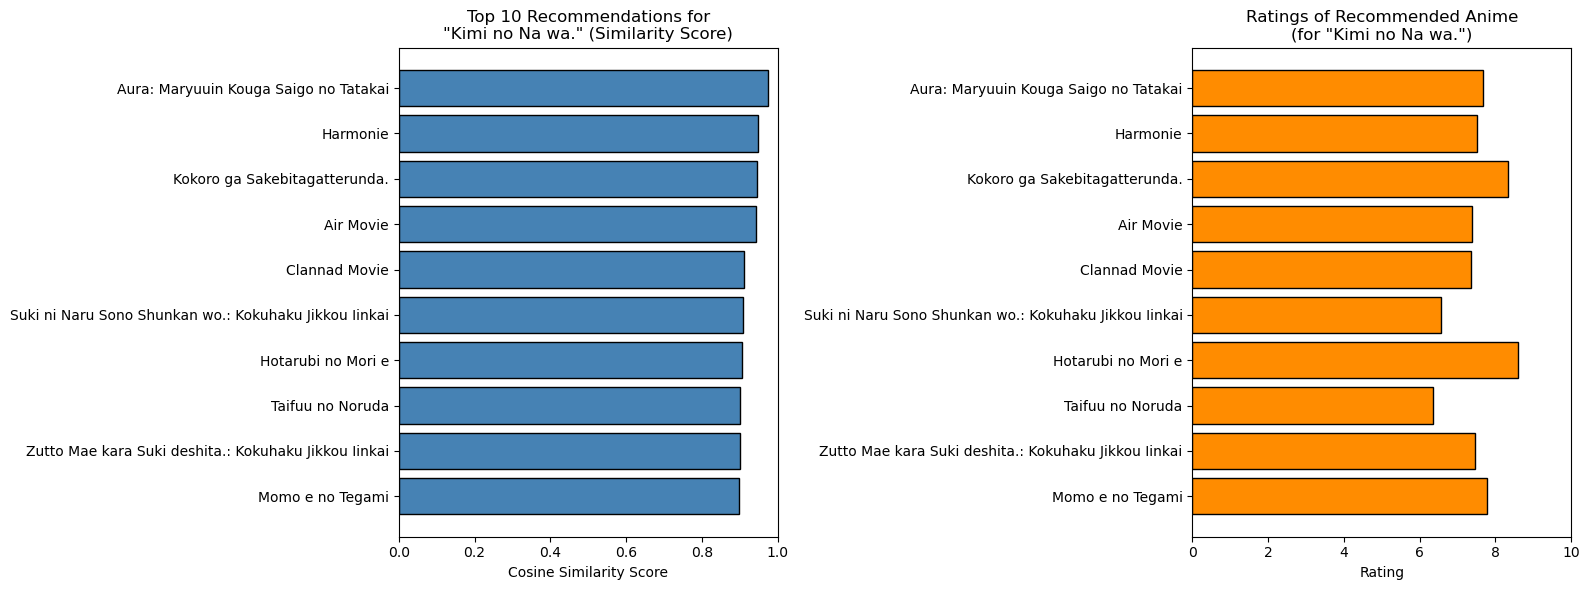

In [16]:
#Visualize Recommendations
def plot_recommendations(anime_name, top_n=10):
    rec = get_recommendations(anime_name, top_n=top_n)
    if rec is None:
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Similarity scores bar chart
    axes[0].barh(rec['name'][::-1], rec['similarity_score'][::-1],
                 color='steelblue', edgecolor='black')
    axes[0].set_title(f'Top {top_n} Recommendations for\n"{anime_name}" (Similarity Score)')
    axes[0].set_xlabel('Cosine Similarity Score')
    axes[0].set_xlim(0, 1)

    # Rating bar chart
    axes[1].barh(rec['name'][::-1], rec['rating'][::-1],
                 color='darkorange', edgecolor='black')
    axes[1].set_title(f'Ratings of Recommended Anime\n(for "{anime_name}")')
    axes[1].set_xlabel('Rating')
    axes[1].set_xlim(0, 10)

    plt.tight_layout()
    plt.savefig(f'recommendations_{anime_name[:10].replace(" ","_")}.png')
    plt.show()

plot_recommendations("Death Note", top_n=10)
plot_recommendations("Kimi no Na wa.", top_n=10)

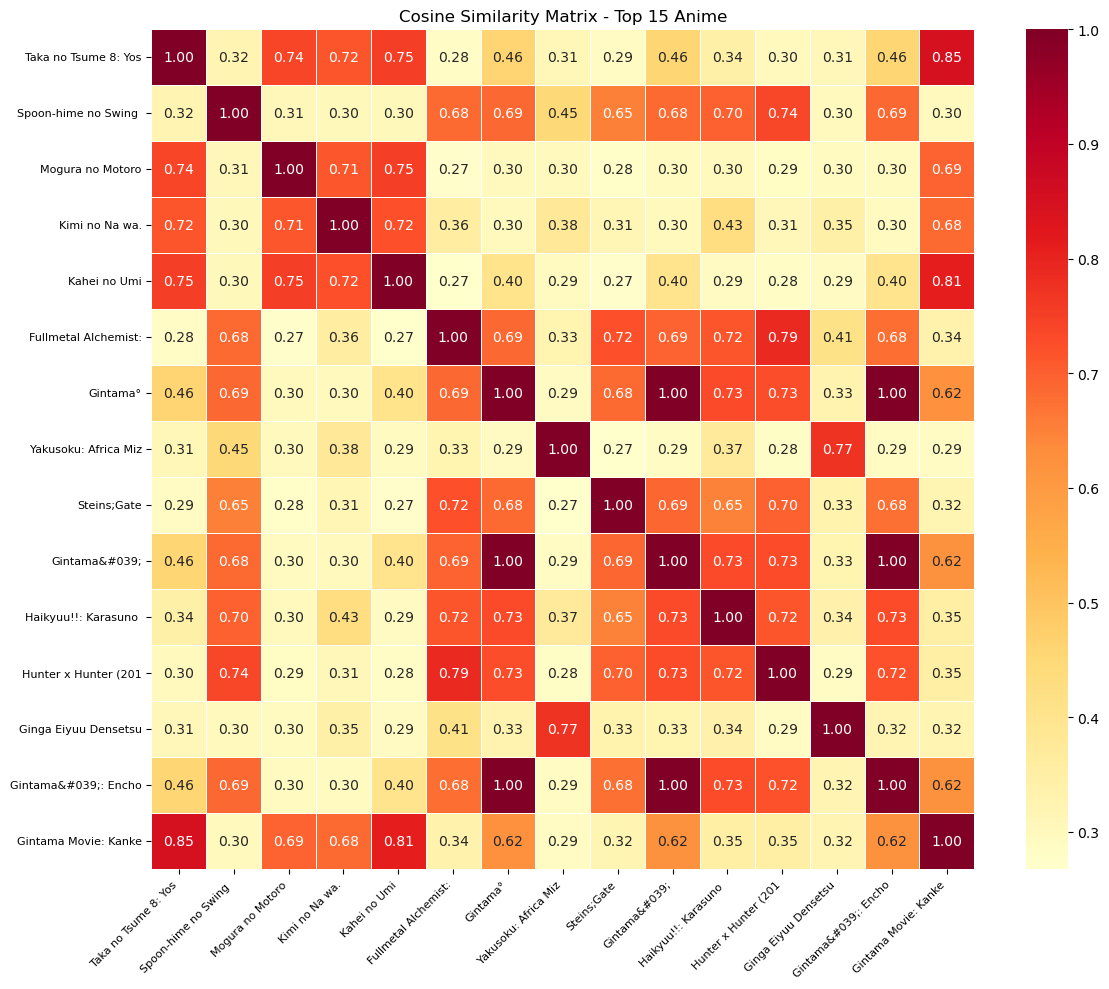

In [17]:
#Cosine Similarity Heatmap (Top 15 Anime)
top15 = df.nlargest(15, 'rating')
top15_idx = top15.index.tolist()
top15_matrix = feature_matrix[top15_idx]
sim_matrix = cosine_similarity(top15_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix,
            xticklabels=[n[:20] for n in top15['name'].tolist()],
            yticklabels=[n[:20] for n in top15['name'].tolist()],
            cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Cosine Similarity Matrix - Top 15 Anime')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png')
plt.show()

## Interview Questions

### Q1: Can you explain the difference between user-based and item-based collaborative filtering?

**User-Based Collaborative Filtering:**
- Finds users who are similar to the target user based on their past behavior
  (e.g., ratings, watch history).
- Recommends items that similar users liked but the target user hasn't seen yet.
- Example: "Users who liked the same anime as you also liked Steins;Gate."
- Weakness: Scales poorly with large user bases. New users with no history
  (cold start problem) get poor recommendations.

**Item-Based Collaborative Filtering:**
- Finds items (anime) that are similar to items the target user already liked,
  based on how users collectively rated them.
- Recommends items similar to what the user has already interacted with.
- Example: "Because you watched Death Note, we recommend similar mystery
  thriller anime like Monster."
- Advantage: More stable than user-based as item relationships change less
  frequently than user preferences. More scalable for large datasets.

| Aspect | User-Based | Item-Based |
|---|---|---|
| Focus | User similarity | Item similarity |
| Scalability | Poor (many users) | Better (fewer items) |
| Cold Start | Severe problem | Less severe |
| Stability | Changes with user behavior | More stable over time |
| Best for | Small communities | Large-scale systems |

---

### Q2: What is collaborative filtering, and how does it work?

**Collaborative Filtering (CF)** is a recommendation technique that predicts
a user's preferences based on the collective behavior of many users —
"collaborating" across user histories to make predictions.

**How it works:**
1. **Data Collection:** Collect user-item interaction data (ratings, views,
   likes) and build a user-item matrix.
2. **Similarity Computation:** Compute similarity between users (user-based)
   or between items (item-based) using metrics like cosine similarity,
   Pearson correlation, or Jaccard similarity.
3. **Prediction:** For a target user, identify the K most similar users
   (or items) and aggregate their ratings/preferences to predict unseen items.
4. **Recommendation:** Return the top-N items with the highest predicted scores.

**Key Assumptions:**
- Users who agreed in the past will agree in the future.
- User preferences are somewhat stable over time.

**Limitations:**
- **Cold Start Problem:** Cannot recommend to new users or new items with
  no interaction history.
- **Sparsity:** Most users rate very few items, making the matrix very sparse.
- **Scalability:** Pairwise similarity computation is expensive for millions
  of users or items.

**Our Implementation:**
In this assignment, we used **content-based filtering** with cosine similarity
on anime features (genre TF-IDF + type + rating + members). This overcomes
the cold start problem since recommendations rely on item attributes rather
than user history, making it suitable for datasets without explicit user-item
rating matrices.